# EDA: Class Balance for Both Heads

Measures the *real* class distribution for Head A (Product) and Head B (Priority) before any decision is made about train/val/test split strategy or class weighting — per the build plan, committing to a split before seeing the actual distribution is guessing.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import psycopg
from dotenv import load_dotenv

load_dotenv()

conn = psycopg.connect(
    host=os.environ["POSTGRES_HOST"],
    port=os.environ["POSTGRES_PORT"],
    dbname=os.environ["POSTGRES_DB"],
    user=os.environ["POSTGRES_USER"],
    password=os.environ["POSTGRES_PASSWORD"],
)

pd.set_option("display.max_rows", 30)

## Head A — Product category balance

Over the full `narrative_consented` population (3,821,652 rows), not just the 250K sample, so the sample's representativeness can be checked against it afterward.

In [2]:
product_counts = pd.read_sql(
    """
    SELECT product, count(*) AS n
    FROM narrative_consented
    GROUP BY product
    ORDER BY n DESC;
    """,
    conn,
)
product_counts["pct"] = (100 * product_counts["n"] / product_counts["n"].sum()).round(2)
product_counts

/var/folders/rn/rzkx3h8j577b27w7ln9mjg4c0000gn/T/ipykernel_35911/1892263228.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_counts = pd.read_sql(


,product,n,pct
0,Credit reporting or other personal consumer re...,1671266,43.73
1,"Credit reporting, credit repair services, or o...",807503,21.13
2,Debt collection,436228,11.41
3,Checking or savings account,183880,4.81
4,Mortgage,145206,3.80
5,Credit card,124114,3.25
6,"Money transfer, virtual currency, or money ser...",119425,3.12
7,Credit card or prepaid card,108683,2.84
8,Student loan,62057,1.62
9,Vehicle loan or lease,52288,1.37


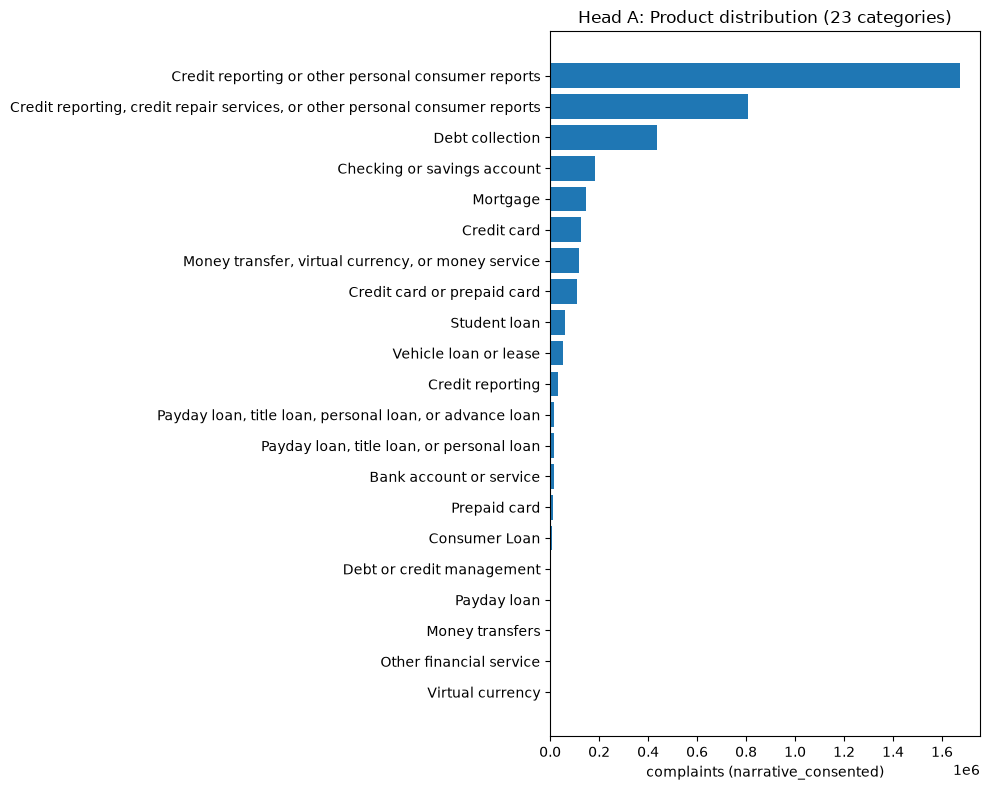

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(product_counts["product"], product_counts["n"])
ax.invert_yaxis()
ax.set_xlabel("complaints (narrative_consented)")
ax.set_title("Head A: Product distribution (23 categories)")
plt.tight_layout()
plt.savefig("reports/product_distribution.png", dpi=110)
plt.show()

## Head B — Priority bucket balance

Computed by the `priority_label` view over the same population.

In [4]:
priority_counts = pd.read_sql(
    """
    SELECT priority_bucket, count(*) AS n
    FROM priority_label
    GROUP BY priority_bucket
    ORDER BY n DESC;
    """,
    conn,
)
priority_counts["pct"] = (100 * priority_counts["n"] / priority_counts["n"].sum()).round(2)
priority_counts

/var/folders/rn/rzkx3h8j577b27w7ln9mjg4c0000gn/T/ipykernel_35911/4073775629.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  priority_counts = pd.read_sql(


,priority_bucket,n,pct
0,Low,3645468,95.39
1,Medium,172633,4.52
2,High,3551,0.09


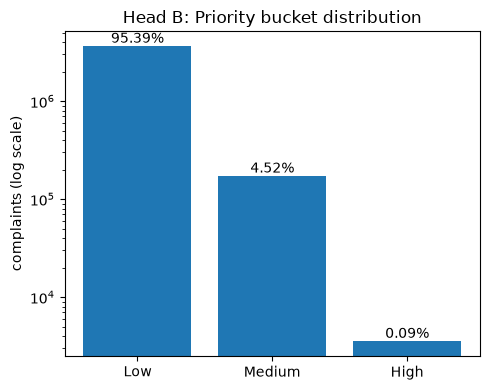

In [5]:
order = ["Low", "Medium", "High"]
pc = priority_counts.set_index("priority_bucket").reindex(order)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(pc.index, pc["n"])
ax.set_yscale("log")
ax.set_ylabel("complaints (log scale)")
ax.set_title("Head B: Priority bucket distribution")
for i, (n, pct) in enumerate(zip(pc["n"], pc["pct"])):
    ax.text(i, n, f"{pct}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("reports/priority_distribution.png", dpi=110)
plt.show()

## Does High priority cluster in specific products?

If High-priority complaints are concentrated in a handful of products rather than spread evenly, that matters for stratified splitting — a product with very few High-priority examples risks having zero of them land in a given split.

In [6]:
crosstab = pd.read_sql(
    """
    SELECT nc.product, pl.priority_bucket, count(*) AS n
    FROM narrative_consented nc
    JOIN priority_label pl USING (complaint_id)
    GROUP BY nc.product, pl.priority_bucket;
    """,
    conn,
)
pivot = crosstab.pivot(index="product", columns="priority_bucket", values="n").fillna(0).astype(int)
pivot = pivot[["Low", "Medium", "High"]]
pivot["total"] = pivot.sum(axis=1)
pivot["high_pct"] = (100 * pivot["High"] / pivot["total"]).round(2)
pivot.sort_values("High", ascending=False)

/var/folders/rn/rzkx3h8j577b27w7ln9mjg4c0000gn/T/ipykernel_35911/154489358.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  crosstab = pd.read_sql(


priority_bucket,Low,Medium,High,total,high_pct
product,,,,,
Debt collection,386638,47807,1783,436228,0.41
"Money transfer, virtual currency, or money service",106926,11951,548,119425,0.46
Checking or savings account,154555,28994,331,183880,0.18
Credit card or prepaid card,86944,21527,212,108683,0.20
Credit card,101763,22193,158,124114,0.13
Bank account or service,10892,3882,109,14883,0.73
Mortgage,138018,7103,85,145206,0.06
"Credit reporting, credit repair services, or other personal consumer reports",801308,6116,79,807503,0.01
Student loan,55080,6915,62,62057,0.10


In [7]:
top_high = pivot.sort_values("High", ascending=False)
top3_share = 100 * top_high["High"].head(3).sum() / top_high["High"].sum()
print(f"Top 3 products by High count account for {top3_share:.1f}% of all High-priority complaints:")
print(top_high["High"].head(3))
print()
print("Meanwhile the two largest products by volume (65% of all complaints combined) are nearly absent from High:")
print(top_high.loc[["Credit reporting or other personal consumer reports", "Credit reporting, credit repair services, or other personal consumer reports"], ["total", "High", "high_pct"]])

Top 3 products by High count account for 75.0% of all High-priority complaints:
product
Debt collection                                       1783
Money transfer, virtual currency, or money service     548
Checking or savings account                            331
Name: High, dtype: int64

Meanwhile the two largest products by volume (65% of all complaints combined) are nearly absent from High:
priority_bucket                                       total  High  high_pct
product                                                                    
Credit reporting or other personal consumer rep...  1671266     5      0.00
Credit reporting, credit repair services, or ot...   807503    79      0.01


## Sanity check: does the stratified sample preserve both distributions?

`product_stratified_sample` was built to preserve Product proportions by construction. It was *not* explicitly stratified on Priority — worth checking whether Priority's distribution survived anyway (it should, approximately, since Priority isn't correlated with which rows get picked within a product).

In [8]:
sample_priority = pd.read_sql(
    """
    SELECT priority_bucket, count(*) AS n
    FROM product_stratified_sample
    GROUP BY priority_bucket
    ORDER BY n DESC;
    """,
    conn,
)
sample_priority["pct"] = (100 * sample_priority["n"] / sample_priority["n"].sum()).round(2)
comparison = priority_counts.merge(
    sample_priority, on="priority_bucket", suffixes=("_population", "_sample")
)
comparison

/var/folders/rn/rzkx3h8j577b27w7ln9mjg4c0000gn/T/ipykernel_35911/1980404989.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sample_priority = pd.read_sql(


,priority_bucket,n_population,pct_population,n_sample,pct_sample
0,Low,3645468,95.39,238648,95.46
1,Medium,172633,4.52,11138,4.46
2,High,3551,0.09,224,0.09


## Summary

- **Head A (Product)** is imbalanced but not extreme: the top category is ~44% of the data, and there are 23 categories total (more than the build plan's ~12-19 estimate) with a long tail of small ones — macro F1 and/or capping the smallest categories into "Other" are both worth considering once modeling starts.
- **Head B (Priority)** is severely imbalanced: Low dominates (95.4%), High is a fraction of a percent (0.09%, 3,551 rows). This matches the build plan's own anticipated risk.
- **Priority and Product are entangled**: High-priority complaints are heavily concentrated in `Debt collection`, `Money transfer/virtual currency`, and `Checking or savings account` (75% of all High between just those three), while the two `Credit reporting` categories — which together are 65% of the *entire* dataset — contribute almost no High-priority examples (0.000% and 0.010% respectively). A product-only stratified split does not guarantee even High-priority representation across train/val/test; the split strategy likely needs to stratify on Priority directly (or jointly on Product x Priority) to avoid a fold with too few or zero High examples.